In [28]:
!pip install opencv-python

El objetivo de este ejercicio, es recrear una imagen, partiendo de matrices de puntos aleatorios

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys
import os
from concurrent.futures import ThreadPoolExecutor
from gens import poblacion, gen


La función usada para calcular la aptitud del individuo. Obtener un menor Diferencia Cuadrática Media **(MSE)** significa una imagen más similar al objetivo. Convertimos el error a una métrica positiva para las probabilidades del algoritmo genético maximizando (65025 - MSE).

In [30]:
def calcular_aptitud(gen_value, objetivo):
    mse = np.mean((gen_value - objetivo) ** 2)
    return 65025.0 - mse

Se condensa todo el proceso de evolución presentado en el punto 1 en una función, con el fin de poder realizar el proceso de forma paralela y optimizar el tiempo de ejecución. 

In [31]:
def evolucionar_poblacion(pb, objetivo, prob_mutacion, tamano_inicial, largo, ancho):
    # Elitismo: preservamos a los mejores individuos directamente
    sl = pb.elitismo(min(10, pb.tamano))
    
    # Completar los demás usando selección por torneo
    sl = pb.seleccion_torneo(seleccionados=sl)
    sl.tamano_inicial = tamano_inicial
    
    # Aplicar cruces
    sl.cruce()
    
    # Aplicar mutaciones para explorar el espacio de búsqueda
    for i in range(sl.tamano):
        if np.random.rand() < prob_mutacion:
            sl.genes[i].mutacion()
        
        # Mutación extra para inyectar diversidad en genes estancados
        if np.random.rand() < 0.2:
            l_i = np.random.randint(0, largo)
            a_i = np.random.randint(0, ancho)
            sl.genes[i].value[l_i, a_i] = np.random.randint(0, 256)
            
    # Evaluar la nueva población generada
    for i in range(sl.tamano):
        sl.genes[i].aptitud = calcular_aptitud(sl.genes[i].value, objetivo)
        
    sl.actualizar()
    pb.actualizar()
    
    # Conservamos la mejor población global si hemos mejorado o no empeorado mucho
    if sl.aptitud_maxima >= pb.aptitud_maxima * 0.999:
        pb = sl
        
    pb.actualizar()
    pb.ordenar() # Mueve el mejor individuo al índice 0
    return pb


Se carga la imagen objetivo y se divide en canales, con el objetivo de reducir la complejidad del problema, de esta manera, cada solución debe encontrar un unico canal que se acerque lo mas posible al objetivo, en lugar de encontrar tres canales que juntos formen la imagen objetivo.
Adicionalmente se fija el tamaño de la población, el numero de generaciones, la probabilidad de mutación y las poblaciones iniciales.

In [32]:
# 1. Cargar y preparar imagen objetivo
ruta_imagen = os.path.join('mariposa.jpg')
if os.path.exists(ruta_imagen):
    # Leer en RGB
    img_original = cv2.imread(ruta_imagen)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    print(f"Imagen objetivo cargada desde: {ruta_imagen}")
else:
    # Generar imagen de prueba si no existe
    print("Imagen 'otra.jpeg' no encontrada, usando objetivo generado por defecto.")
    img_original = np.zeros((32, 32, 3), dtype=np.uint8)
    cv2.circle(img_original, (16, 16), 10, (255, 0, 0), -1)
    cv2.circle(img_original, (20, 20), 8, (0, 255, 0), -1)
    cv2.circle(img_original, (12, 20), 8, (0, 0, 255), -1)
    
l = 180
a = 120
objetivo = cv2.resize(img_original, (l,a))
largo, ancho, canales = objetivo.shape

# Extraer canales
objetivo_R = objetivo[:, :, 0]
objetivo_G = objetivo[:, :, 1]
objetivo_B = objetivo[:, :, 2]

# Parámetros del algoritmo
tamano_inicial = 50
generaciones = 5000
prob_mutacion = 0.8 # Probabilidad alta debido al espacio de búsqueda 256^N

# 2. Inicializar población paramétrica para cada canal
# Usamos el tipo "entero" porque los píxeles van de 0 a 255
pb_R = poblacion(tamano_inicial, ancho, largo, "entero", 256, 0)
pb_G = poblacion(tamano_inicial, ancho, largo, "entero", 256, 0)
pb_B = poblacion(tamano_inicial, ancho, largo, "entero", 256, 0)

lista_gen = []
lista_mse_min = []

Imagen objetivo cargada desde: mariposa.jpg


Ejecución paralela del proceso de evolución, con la ayuda de ThreadPoolExecutor.

In [33]:
# Evaluación inicial de aptitud separada por canal
for i in range(tamano_inicial):
    pb_R.genes[i].aptitud = calcular_aptitud(pb_R.genes[i].value, objetivo_R)
    pb_G.genes[i].aptitud = calcular_aptitud(pb_G.genes[i].value, objetivo_G)
    pb_B.genes[i].aptitud = calcular_aptitud(pb_B.genes[i].value, objetivo_B)
    
pb_R.actualizar()
pb_G.actualizar()
pb_B.actualizar()

# Uso de ThreadPoolExecutor para ejecutar la evolución de los tres canales en paralelo
with ThreadPoolExecutor(max_workers=3) as executor:
    for gen_idx in range(generaciones):
        # Submitimos las 3 tareas
        futures = [
            executor.submit(evolucionar_poblacion, pb_R, objetivo_R, prob_mutacion, tamano_inicial, largo, ancho),
            executor.submit(evolucionar_poblacion, pb_G, objetivo_G, prob_mutacion, tamano_inicial, largo, ancho),
            executor.submit(evolucionar_poblacion, pb_B, objetivo_B, prob_mutacion, tamano_inicial, largo, ancho)
        ]
        
        # Obtenemos los resultados sincronizados
        pb_R = futures[0].result()
        pb_G = futures[1].result()
        pb_B = futures[2].result()
        
        lista_gen.append(gen_idx)
        
        mejor_mse_R = 65025.0 - pb_R.aptitud_maxima
        mejor_mse_G = 65025.0 - pb_G.aptitud_maxima
        mejor_mse_B = 65025.0 - pb_B.aptitud_maxima
        mse_promedio = (mejor_mse_R + mejor_mse_G + mejor_mse_B) / 3.0
        
        lista_mse_min.append(mse_promedio)
        
        if (gen_idx+1) % 100 == 0:
            print(f"Generación: {gen_idx+1:04d} | MSE Promedio: {mse_promedio:6.2f} (R: {mejor_mse_R:6.2f}, G: {mejor_mse_G:6.2f}, B: {mejor_mse_B:6.2f})")

Generación: 0100 | MSE Promedio: 9675.83 (R: 9584.55, G: 8988.74, B: 10454.19)
Generación: 0200 | MSE Promedio: 9461.76 (R: 9367.01, G: 8789.10, B: 10229.17)
Generación: 0300 | MSE Promedio: 9252.53 (R: 9166.36, G: 8583.23, B: 10008.00)
Generación: 0400 | MSE Promedio: 9052.31 (R: 8962.95, G: 8389.30, B: 9804.69)
Generación: 0500 | MSE Promedio: 8851.92 (R: 8760.89, G: 8204.23, B: 9590.63)
Generación: 0600 | MSE Promedio: 8658.94 (R: 8569.25, G: 8025.57, B: 9382.01)
Generación: 0700 | MSE Promedio: 8463.04 (R: 8374.98, G: 7847.85, B: 9166.29)
Generación: 0800 | MSE Promedio: 8277.44 (R: 8182.91, G: 7674.56, B: 8974.85)
Generación: 0900 | MSE Promedio: 8099.30 (R: 8011.67, G: 7513.37, B: 8772.85)
Generación: 1000 | MSE Promedio: 7912.65 (R: 7829.87, G: 7348.55, B: 8559.53)
Generación: 1100 | MSE Promedio: 7728.84 (R: 7641.18, G: 7175.66, B: 8369.66)
Generación: 1200 | MSE Promedio: 7559.67 (R: 7467.88, G: 7014.87, B: 8196.27)
Generación: 1300 | MSE Promedio: 7394.85 (R: 7292.63, G: 6855

Presentación de los resultados del algoritmo genético para la reconstrucción de una imagen.

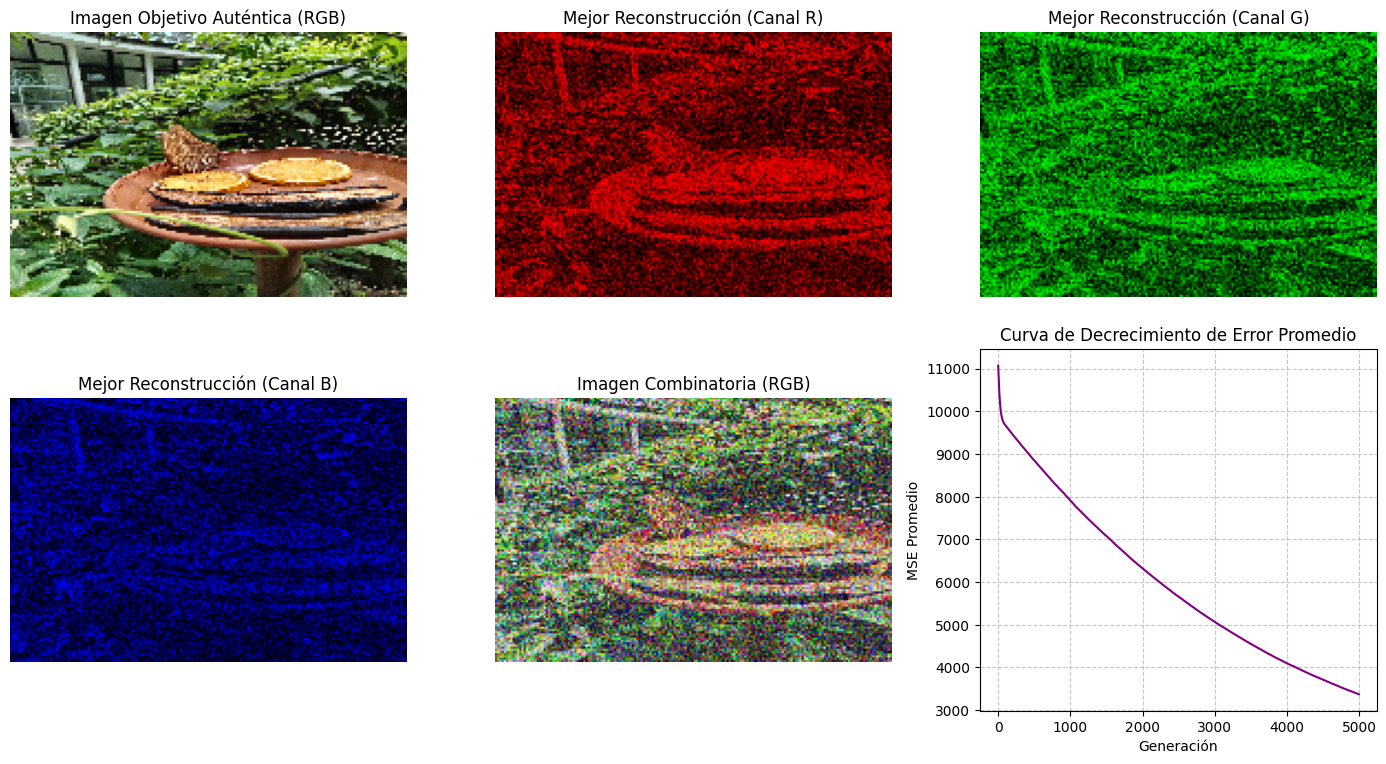

In [34]:

# 3. Mostrar resultados y gráficas
mejor_reconstruccion_R = pb_R.genes[0].value
mejor_reconstruccion_G = pb_G.genes[0].value
mejor_reconstruccion_B = pb_B.genes[0].value

# Generar imágenes exclusivas por canal
img_R = np.zeros((largo, ancho, 3), dtype=np.uint8)
img_R[:, :, 0] = mejor_reconstruccion_R

img_G = np.zeros((largo, ancho, 3), dtype=np.uint8)
img_G[:, :, 1] = mejor_reconstruccion_G

img_B = np.zeros((largo, ancho, 3), dtype=np.uint8)
img_B[:, :, 2] = mejor_reconstruccion_B

# Generar imagen combinatoria RGB
img_combinada = np.zeros((largo, ancho, 3), dtype=np.uint8)
img_combinada[:, :, 0] = mejor_reconstruccion_R
img_combinada[:, :, 1] = mejor_reconstruccion_G
img_combinada[:, :, 2] = mejor_reconstruccion_B

plt.figure(figsize=(14, 8))

# Subplot 1: Objetivo
plt.subplot(2, 3, 1)
plt.imshow(objetivo)
plt.title("Imagen Objetivo Auténtica (RGB)")
plt.axis("off")

# Subplot 2: Canal R
plt.subplot(2, 3, 2)
plt.imshow(img_R)
plt.title("Mejor Reconstrucción (Canal R)")
plt.axis("off")

# Subplot 3: Canal G
plt.subplot(2, 3, 3)
plt.imshow(img_G)
plt.title("Mejor Reconstrucción (Canal G)")
plt.axis("off")

# Subplot 4: Canal B
plt.subplot(2, 3, 4)
plt.imshow(img_B)
plt.title("Mejor Reconstrucción (Canal B)")
plt.axis("off")

# Subplot 5: Combinatoria
plt.subplot(2, 3, 5)
plt.imshow(img_combinada)
plt.title("Imagen Combinatoria (RGB)")
plt.axis("off")

# Subplot 6: Curva de convergencia (MSE Promedio)
plt.subplot(2, 3, 6)
plt.plot(lista_gen, lista_mse_min, color='purple')
plt.title("Curva de Decrecimiento de Error Promedio")
plt.xlabel("Generación")
plt.ylabel("MSE Promedio")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("P4_imagen.png", dpi=300, bbox_inches='tight')
plt.show()